# PC-Kriging, bootstrap voting and active importance sampling

PySTRA's scope is **a carefully validated implementation of established and selected modern structural reliability methods**, with practical code calibration and assessment tools. This tutorial composes three additions within that scope:

1. Sequential PC-Kriging with uncertainty from an estimated polynomial trend.
2. Failed-bootstrap-replicates (FBR) learning with actual classification votes.
3. Active importance sampling with explicit proposals and likelihood weights.

The [method guide](../active_learning.rst) and downloadable provenance note distinguish implemented variants from the original papers. This tutorial uses PC-Kriging and PCE, which need only NumPy/SciPy. Standard Kriging remains available through `pystra[al]`. No UQLab runtime is required.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.stats import norm
import pystra as ra
from pystra.active_learning import (
    ActiveLearning,
    AllCriteria,
    BetaBounds,
    BetaStability,
    BootstrapBounds,
    LearningThreshold,
    ImportanceSamplingEstimator,
)


## PC-Kriging on the four-branch benchmark

[Schöbi, Sudret and Wiart (2015)](https://doi.org/10.1615/Int.J.UncertaintyQuantification.2015012467) combine a polynomial trend with a correlated residual. We implement the **sequential** variant: select a sparse trend, then estimate its coefficients by generalized least squares for each covariance candidate. Prediction variance includes uncertainty in those coefficients. Fitting a GP to residuals while treating the trend as known would omit this term.

For the standard four-branch problem, independent $X_0,X_1\sim N(0,1)$ define rotated coordinates $A=(X_0+X_1)/\sqrt2$ and $D=(X_0-X_1)/\sqrt2$:

$$g=\min\{3+0.2D^2-|A|,\sqrt2(3-|D|)\}.$$

Failure is $g\le0$. Its four regions provide a useful discovery check. Rotation also supplies an independent one-dimensional probability integral; see the [earlier benchmark tutorial](ex_active_learning.ipynb) for attribution and derivation.

In [2]:
def normal_model():
    model = ra.StochasticModel()
    model.add_variable(ra.Normal("x0", 0, 1))
    model.add_variable(ra.Normal("x1", 0, 1))
    return model


def four_branch(x0, x1):
    along = (x0 + x1) / np.sqrt(2)
    across = (x0 - x1) / np.sqrt(2)
    return np.minimum(
        3 + 0.2 * across**2 - np.abs(along), np.sqrt(2) * (3 - np.abs(across))
    )


four_reference = (
    2 * norm.sf(3)
    + quad(lambda d: 2 * norm.sf(3 + 0.2 * d**2) * norm.pdf(d), -3, 3, epsabs=1e-13)[0]
)
pc_analysis = ActiveLearning(
    stochastic_model=normal_model(),
    limit_state=ra.LimitState(four_branch),
    surrogate="pc_kriging",
    surrogate_kwargs={"degree": (1, 2, 3)},
    n_initial=50,
    n_candidates=12000,
    n_estimation=100000,
    learning_threshold=3,
    max_iterations=200,
    seed=7,
    stopping_criterion=AllCriteria(
        criteria=(
            LearningThreshold(),
            BetaBounds(consecutive=2),
            BetaStability(consecutive=2),
        )
    ),
)
pc_result = pc_analysis.run()
assert pc_result.converged
print(
    f"PC-Kriging Pf: {pc_result.failure_probability:.6f}; reference: {four_reference:.6f}"
)
print(
    f"True model calls: {pc_result.n_evaluations}; sampling CoV: {pc_result.sampling_cov:.3f}"
)
print(f"Selected degree: {pc_analysis.surrogate_model.fit_result.trend.degree}")


PC-Kriging Pf: 0.004400; reference: 0.004457
True model calls: 115; sampling CoV: 0.048
Selected degree: 2


This run uses anisotropic Matérn 5/2 correlation, consistent with PySTRA's existing Kriging surrogate. Gaussian correlation is available through `correlation="gaussian"`. Smooth-kernel assumptions can be too confident on nonsmooth responses; the regression tests check each failure region independently. Kernel and trend-selection uncertainty are not included in the reported predictive variance. The stopping policy combines U ≥ 3 with beta bounds and stability.

Misclassified probability mass / reference Pf: 4.04%


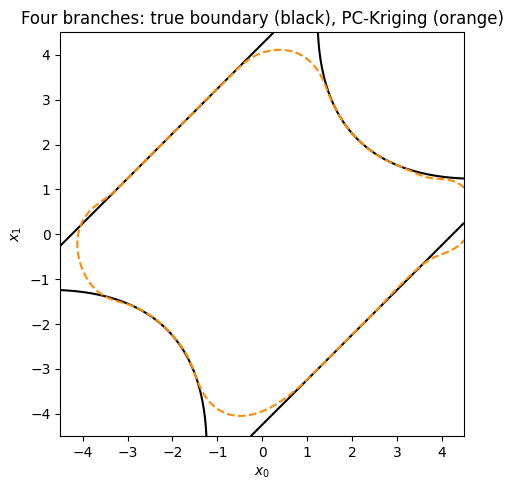

In [3]:
points = np.random.default_rng(892).normal(size=(100000, 2))
truth = four_branch(*points.T) <= 0
prediction = pc_analysis.surrogate_model.predict(points)[0] <= 0
print(
    f"Misclassified probability mass / reference Pf: {np.mean(truth != prediction) / four_reference:.2%}"
)
assert np.mean(truth != prediction) < 0.1 * four_reference
along = points.sum(axis=1) / np.sqrt(2)
across = (points[:, 0] - points[:, 1]) / np.sqrt(2)
for region in (
    along > 3 + 0.2 * across**2,
    along < -3 - 0.2 * across**2,
    across > 3,
    across < -3,
):
    assert np.mean(~prediction[region]) < 0.15

axis = np.linspace(-4.5, 4.5, 120)
x0, x1 = np.meshgrid(axis, axis)
query = np.column_stack((x0.ravel(), x1.ravel()))
predicted = pc_analysis.surrogate_model.predict(query)[0].reshape(x0.shape)
fig, ax = plt.subplots(figsize=(6, 5))
ax.contour(x0, x1, four_branch(x0, x1), levels=[0], colors="black")
ax.contour(x0, x1, predicted, levels=[0], colors="darkorange", linestyles="--")
ax.set(
    xlabel="$x_0$",
    ylabel="$x_1$",
    title="Four branches: true boundary (black), PC-Kriging (orange)",
)
ax.set_aspect("equal")
fig.tight_layout()
plt.show()


## FBR on a lognormal beam

[Marelli and Sudret (2018)](https://doi.org/10.1016/j.strusafe.2018.06.003) use bootstrap classification disagreement to select new evaluations:

$$U_{\rm FBR}=\frac{|B_{\rm safe}-B_{\rm failure}|}{B}.$$

Zero means equal safe/failure votes; one means unanimity. Predictions with $g=0$ count as failures. The implementation uses actual replicate responses rather than converting their mean and standard deviation into Gaussian probabilities.

For a simply supported rectangular beam under uniform load,

$$g=0.015-\frac{5pL^4}{32Ebh^3}.$$

Lengths are in metres, $p$ in MN/m and $E$ in MN/m² (MPa). All five inputs are independent lognormal variables. The displacement is therefore exactly lognormal, supplying an independent probability reference.

In [4]:
names = ("b", "h", "length", "elasticity", "load")
means = np.array([0.15, 0.3, 5, 30000, 0.01])
stds = means * np.array([0.05, 0.05, 0.01, 0.15, 0.2])
beam_model = ra.StochasticModel()
for name, mean, std in zip(names, means, stds):
    beam_model.add_variable(ra.Lognormal(name, mean, std))


def beam(b, h, length, elasticity, load):
    return 0.015 - 5 * load * length**4 / (32 * elasticity * b * h**3)


powers = np.array([-1, -3, 4, -1, 1])
variance = np.log1p((stds / means) ** 2)
log_mean = np.log(5 / 32) + powers @ (np.log(means) - variance / 2)
log_std = np.sqrt(powers**2 @ variance)
beam_reference = norm.sf((np.log(0.015) - log_mean) / log_std)
fbr_analysis = ActiveLearning(
    stochastic_model=beam_model,
    limit_state=ra.LimitState(beam),
    surrogate="pce",
    surrogate_kwargs={"q_norm": 0.75, "max_interaction": 2},
    learning_function="fbr",
    n_candidates=20000,
    n_estimation=100000,
    seed=7,
)
fbr_result = fbr_analysis.run()
assert fbr_result.converged
print(
    f"FBR/PCE Pf: {fbr_result.failure_probability:.6f}; reference: {beam_reference:.6f}"
)
print(
    f"True model calls: {fbr_result.n_evaluations}; sampling CoV: {fbr_result.sampling_cov:.3f}"
)
assert abs(fbr_result.failure_probability - beam_reference) < (
    4 * np.sqrt(beam_reference * (1 - beam_reference) / fbr_result.n_estimation)
    + 0.05 * beam_reference
)


FBR/PCE Pf: 0.017660; reference: 0.017206
True model calls: 48; sampling CoV: 0.024


Named FBR defaults to `BootstrapBounds(tolerance=0.1, consecutive=2)`: require

$$\frac{\max_b\hat P_f^{(b)}-\min_b\hat P_f^{(b)}}{\hat P_f}\le0.1$$

for two consecutive fits. `LearningStep.bootstrap_probability_band` records these actual probability extremes on the fixed IID normal pool. They are distinct from `probability_band`, which evaluates mean ± two prediction standard deviations.

The bootstrap range need not enclose the full-design estimate. It does not include common model bias or uncertainty in selecting the polynomial basis. PySTRA follows the paper's single-point enrichment option, using a Latin hypercube initial design. Clustered batch enrichment is not implemented.

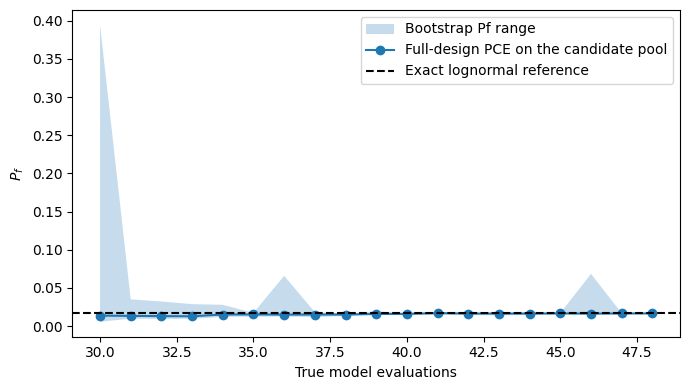

In [5]:
history = fbr_result.history
calls = np.array([step.n_evaluations for step in history])
probabilities = np.array([step.failure_probability for step in history])
bands = np.array([step.bootstrap_probability_band for step in history])
fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(calls, bands[:, 0], bands[:, 1], alpha=0.25, label="Bootstrap Pf range")
ax.plot(calls, probabilities, "o-", label="Full-design PCE on the candidate pool")
ax.axhline(
    beam_reference, color="black", linestyle="--", label="Exact lognormal reference"
)
ax.set(xlabel="True model evaluations", ylabel="$P_f$")
ax.legend()
fig.tight_layout()
plt.show()

# Independent physical mapping checks the fitted response away from training.
points = np.random.default_rng(892).normal(size=(100000, 5))
physical = np.exp(np.log(means) - variance / 2 + np.sqrt(variance) * points)
truth = beam(*physical.T) <= 0
prediction = fbr_analysis.surrogate_model.predict(points)[0] <= 0
assert np.mean(truth != prediction) < 0.1 * beam_reference


## Active importance sampling for two rare failure regions

For $g=16-X_0^2$, failure occurs in both tails beyond $\pm4$, with exact probability $2\Phi(-4)$. We supply both centres explicitly and compose the importance estimator with PC-Kriging. This quadratic is exactly representable by its trend; it isolates sampling and proposal geometry from approximation error. A single FORM design point would describe only one of the two modes; this workflow does not discover additional centres automatically.

The proposal is a mixture of two shifted unit-normal distributions and a 10% target-normal component. For each sample $u\sim q$, its contribution is $I(g(u)\le0)\phi(u)/q(u)$. Raw failure proportions in this pool are not failure probabilities. [Echard and colleagues (2013)](https://doi.org/10.1016/j.ress.2012.10.008) introduced the design-point AK-IS approach; this example uses an explicit defensive mixture variant.

In [6]:
def two_tail(x0, x1):
    return 16 - x0**2


estimator = ImportanceSamplingEstimator(
    centers=[[-4, 0], [4, 0]],
    n_samples=10000,
    defensive_fraction=0.1,
)
is_analysis = ActiveLearning(
    stochastic_model=normal_model(),
    limit_state=ra.LimitState(two_tail),
    surrogate="pc_kriging",
    surrogate_kwargs={"degree": (1, 2, 3)},
    estimator=estimator,
    seed=7,
    stopping_criterion=AllCriteria(
        criteria=(BetaBounds(consecutive=2), BetaStability(consecutive=2))
    ),
)
is_result = is_analysis.run()
tail_reference = 2 * norm.sf(4)
assert is_result.converged
print(f"Active IS Pf: {is_result.failure_probability:.8f}; exact: {tail_reference:.8f}")
print(
    f"True model calls: {is_result.n_evaluations}; sampling CoV: {is_result.sampling_cov:.3f}"
)
assert abs(is_result.failure_probability - tail_reference) < (
    4 * tail_reference * is_result.sampling_cov + 0.05 * tail_reference
)
pd.Series(vars(is_result.estimate.diagnostics[0]), name="Sampling diagnostics")


Active IS Pf: 0.00006394; exact: 0.00006334
True model calls: 32; sampling CoV: 0.023


raw_probability          0.000064
standard_error           0.000001
effective_samples     1183.383286
effective_failures    1640.064690
failure_count         4498.000000
mean_weight              1.012956
max_weight               9.969899
Name: Sampling diagnostics, dtype: float64

In [7]:
exploration = estimator.explore(
    is_analysis.surrogate_model.predict,
    dimension=2,
    rng=np.random.default_rng(29),
    n_candidates=1000,
)
print(
    f"Raw fraction classified as failure in the proposal pool: {np.mean(exploration.mean <= 0):.3f}"
)
print(f"Correctly weighted estimate: {exploration.estimate.failure_probability:.8f}")
assert np.mean(exploration.mean <= 0) > 100 * tail_reference
assert is_result.sampling_interval is None


Raw fraction classified as failure in the proposal pool: 0.446
Correctly weighted estimate: 0.00006263


The sampling standard error is the sample standard deviation of the weighted contributions divided by √N. It is conditional on the frozen surrogate; it does not include surrogate error. Effective failure counts, mean/max weights and raw estimates are retained. No binomial interval is attached to weighted samples.

The default defensive component bounds weights, but it cannot prove that an unknown rare failure region was sampled. Centres remain fixed while the surrogate is enriched. Final samples are independent of enrichment. There is no true-model correction factor, and any FORM calls used to obtain proposal centres would be additional to the learning budget.

`BootstrapBounds` is deliberately rejected with importance/subset enrichment because those estimators do not yet supply bootstrap probability ranges under their sampling measures. FBR **selection** can still be combined with them using an explicit alternative stopping policy.

## Validation and limits

Tests repeat these workflows with seeds 7, 23 and 101. They also compare universal prediction with unmodified UQLab routines, check the likelihood gradient and constrained predictor independently, and compare replicated IS errors with analytical rare-event probabilities in 2 and 20 dimensions. Budget exhaustion stays visible. A hidden-mode counterexample demonstrates that bootstrap unanimity alone can coexist with a badly biased estimate.

Independent validation calls in this tutorial are additional to the reported learning costs. These cases provide evidence for the specified methods and settings; they do not certify every model or reproduce all settings in the cited papers. The broader organization follows the reviews by [Moustapha, Marelli and Sudret (2022)](https://doi.org/10.1016/j.strusafe.2021.102174) and [Teixeira, Nogal and O’Connor (2021)](https://doi.org/10.1016/j.strusafe.2020.102019).